/home/yogen14/.local/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


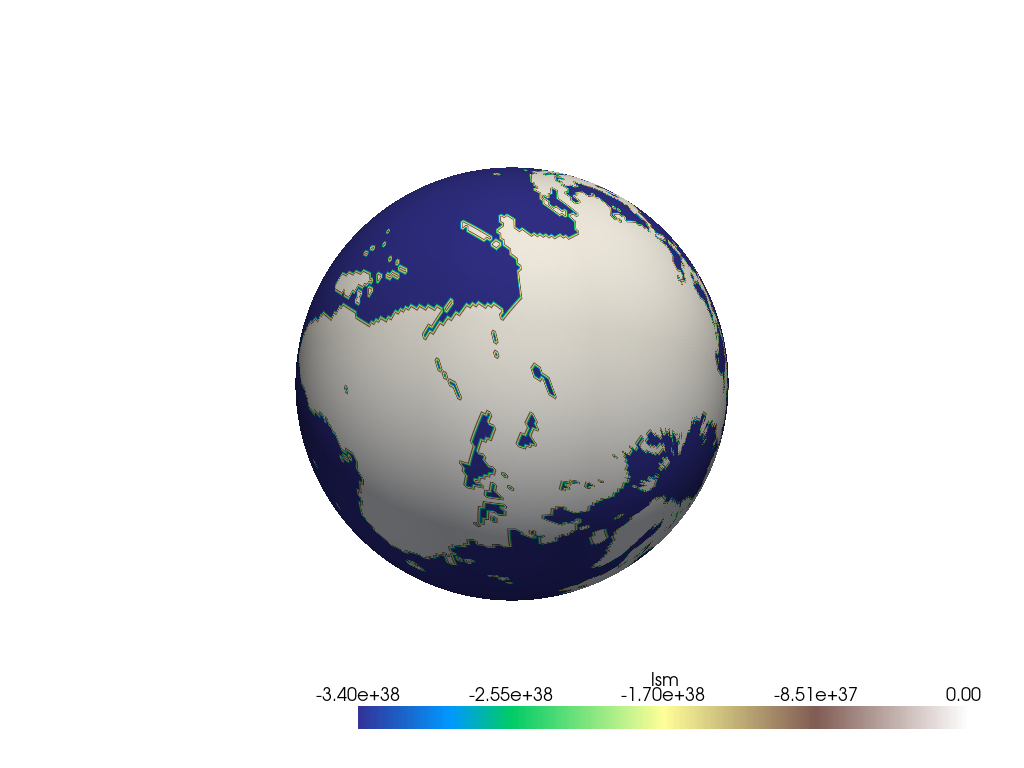

In [1]:
import numpy as np
import pyvista as pv
import tifffile as tiff

# Load the GeoTIFF image using tifffile
image = tiff.imread('/media/sf_Shared_Ubuntu/MAPS/GPW_2020_1deg.tif')
lsm = image  # You don't need to convert to numpy array here

# Create meshgrid for longitude, latitude, and altitude
longitude = np.linspace(-180, 180, image.shape[1])
latitude = np.linspace(90, -90, image.shape[0])  # Reverse the latitude values
altitude = 0  # You can set the altitude to a fixed value, like 0

xx, yy = np.meshgrid(np.radians(longitude), np.radians(latitude))

# Transform to spherical coordinates
radius = 6371.0e6
x = radius * np.cos(yy) * np.cos(xx)
y = radius * np.sin(yy)
z = radius * np.cos(yy) * np.sin(xx)

# Create the PyVista structured grid
grid = pv.StructuredGrid(x, y, z)
grid.point_data['lsm'] = lsm.ravel(order='F')  # Add the data to point data

# Plot the PyVista grid with color mapping
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars='lsm', cmap='terrain')
plotter.show()
